In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 
from sklearn.svm import SVR 
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error 
from sklearn.model_selection import RandomizedSearchCV 
from catboost import CatBoostRegressor 
from xgboost import XGBRegressor 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../notebook/data/stud.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Preparando as features X e Y

In [4]:
X = df.drop(columns=["math_score"], axis=1)

In [5]:
y = df['math_score']

### Vamos transformar colunas categóricas em numéricas

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer 

num_features = X.select_dtypes(exclude=["object"]).columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler() 
oh_transformer = OneHotEncoder() 

preprocessor = ColumnTransformer( 
    [
        ("OneHotEncoder", oh_transformer, cat_features), 
        ("StandardScaler", numeric_transformer, num_features) 
    ]
)




In [7]:
X = preprocessor.fit_transform(X) #Aplica a transformação dos dados aplicas pelo preprocessor

### Separar os dados em treino e teste

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)  #Toda vez que você executar essa célula, os dados serão divididos exatamente da mesma maneira. As mesmas linhas irão para o treino e as mesmas para o teste. Isso é crucial para que você possa comparar resultados.Se você mudar o modelo e a acurácia subir, você saberá que foi por causa da mudança no modelo, e não porque os dados de treino "deram sorte" de serem mais fáceis nessa execução.
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Criar uma função para retornar as métricas do modelo

In [9]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2
    

In [10]:

models = {
    "Linear Regression": LinearRegression(), 
    "Lasso": Lasso(), 
    "Ridge": Ridge(), 
    "K-Neighbors Regressor": KNeighborsRegressor(), 
    "Decision Tree": DecisionTreeRegressor(), 
    "Random Forest Regressor": RandomForestRegressor(), 
    "XGBRegressor": XGBRegressor(), 
    "CatBoostRegressor": CatBoostRegressor(verbose=False), 
    "AdaBoostRegressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i] #O código pega o algoritmo da vez (ex: na primeira volta pega o LinearRegression, na segunda o Lasso, etc.) e guarda na variável model.
    model.fit(X_train, y_train) # modelo de treinamento

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)  # fazendo a predição

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2  = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print("-  Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- Mean Squared Error: {:.4f}".format(model_train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    print("")


    print('-----------------')
    print('Model performance for test set')
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- Mean Squared Error: {:.4f}".format(model_test_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print('='*35)
    print('\n')





Linear Regression
Model performance for training set
-  Mean Absolute Error: 4.2667
- Mean Squared Error: 28.3349
- Root Mean Squared Error: 5.3231
- R2 Score: 0.8743

-----------------
Model performance for test set
- Mean Absolute Error: 4.2148
- Mean Squared Error: 29.0952
- Root Mean Squared Error: 5.3940
- R2 Score: 0.8804


Lasso
Model performance for training set
-  Mean Absolute Error: 5.2063
- Mean Squared Error: 43.4784
- Root Mean Squared Error: 6.5938
- R2 Score: 0.8071

-----------------
Model performance for test set
- Mean Absolute Error: 5.1579
- Mean Squared Error: 42.5064
- Root Mean Squared Error: 6.5197
- R2 Score: 0.8253


Ridge
Model performance for training set
-  Mean Absolute Error: 4.2650
- Mean Squared Error: 28.3378
- Root Mean Squared Error: 5.3233
- R2 Score: 0.8743

-----------------
Model performance for test set
- Mean Absolute Error: 4.2111
- Mean Squared Error: 29.0563
- Root Mean Squared Error: 5.3904
- R2 Score: 0.8806


K-Neighbors Regressor
Model 

In [11]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.853156
7,CatBoostRegressor,0.851632
8,AdaBoostRegressor,0.841720
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.748293


### **Resumo: fit_intercept=True**

Define se o modelo calcula o **Intercepto (b)** na equação:
**y = (m * x) + b**

* **`True` (Padrão):** O modelo calcula o valor de **b**. A reta pode cruzar o eixo Y em qualquer ponto (permite um "valor base").
* **`False`:** Força a reta a passar pela origem (0,0). O valor de **b** é fixado em 0.

**Componentes da Equação:**

* **m (Peso/Inclinação angular):** Indica o quanto **y** aumenta ou diminui para cada 1 unidade de **x**.
* **b (Intercepto/Bias, coeficiente linear):** É o valor de **y** quando o seu **x** é igual a zero.

---


In [12]:
lin_model = LinearRegression(fit_intercept=True) #Você está dizendo ao modelo: "Não me obrigue a passar pelo zero; encontre o melhor ponto de partida para a linha". É o comportamento padrão e geralmente o correto a se usar.
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


#  Análise de Performance: Real vs. Previsto

Este relatório detalha a interpretação do gráfico de dispersão gerado para avaliar o desempenho do modelo de regressão nas notas de matemática.


## Conclusão sobre a Performance

Com base na distribuição observada e nos indicadores técnicos, podemos afirmar que o modelo é **robusto**.

| Indicador | Status | Observação |
| --- | --- | --- |
| **Precisão ()** | ~0.88 | Indica uma alta aderência aos dados reais. |
| **Consistência** | Alta | O modelo diferencia bem alunos de notas altas e baixas. |
| **Padrão de Erro** | Baixo | Não há dispersão caótica; os erros são pontuais. |


> **Nota de destaque:** Embora existam pequenos desvios (como o caso do aluno que tirou ~20 e o modelo previu ~30), a tendência geral mostra que o modelo aprendeu os padrões fundamentais dos dados e as previsões são confiáveis para uso prático.



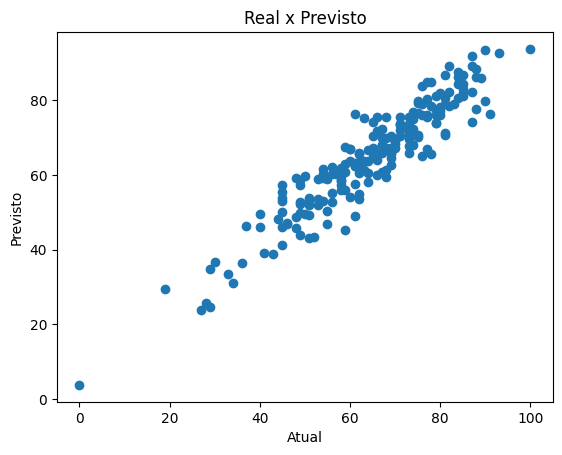

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel('Atual')
plt.ylabel('Previsto')
plt.title('Real x Previsto')
plt.show()

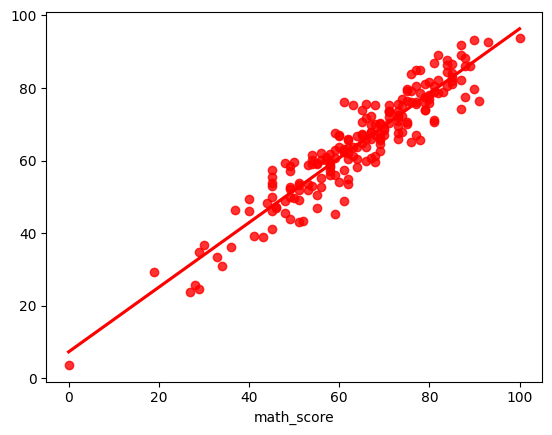

In [ ]:
sns.regplot(x=y_test, y= y_pred, ci=None, color='r'); #Ao colocar ci=None, pedimos para ver apenas a linha de tendência ("o melhor ajuste"), sem a estimativa da margem de incerteza ao redor dela.

### Diferença entre o Atual e Previsto (Notas):

In [20]:
pred_df = pd.DataFrame({'Atual Valor': y_test, 'Valor Previsto': y_pred, 'Difference': y_test-y_pred})
pred_df

,Atual Valor,Valor Previsto,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
